# Logistic Regression - Pima Indians Diabetes Database


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from sklearn.utils import resample
# Load dataset
df=pd.read_csv('Prac3_dataset.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [3]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

Outcome
0    500
1    268
Name: count, dtype: int64


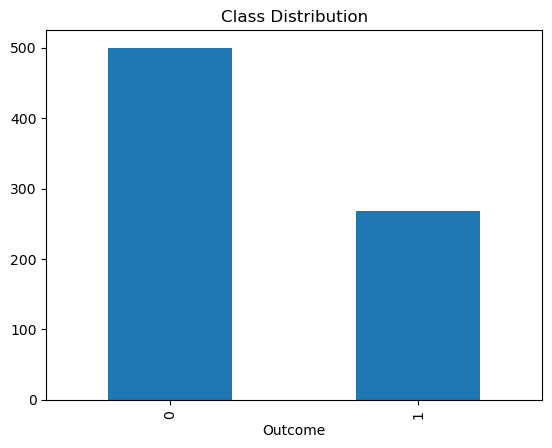

In [4]:
print(df['Outcome'].value_counts())
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

In [5]:
# Replace invalid zeros
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for c in cols:
    df[c]=df[c].replace(0,np.nan)
    df[c]=df[c].fillna(df[c].median())
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


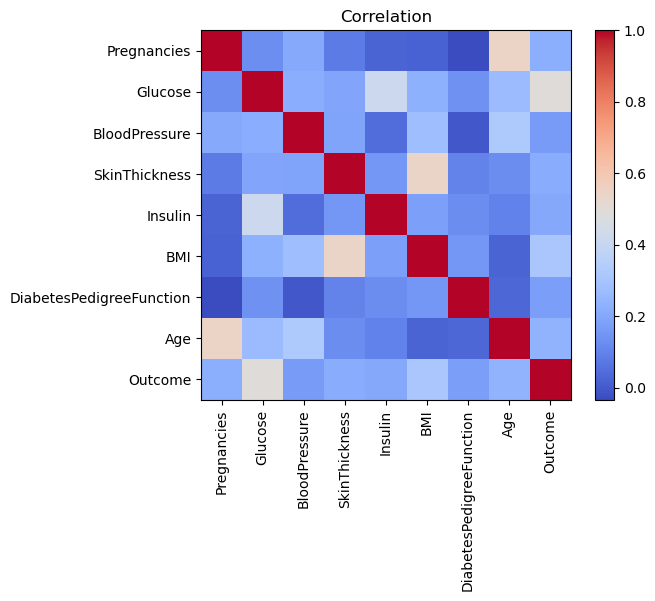

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [13]:
# Correlation
import matplotlib.pyplot as plt
plt.imshow(df.corr(),cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(df.columns)),df.columns,rotation=90)
plt.yticks(range(len(df.columns)),df.columns)
plt.title('Correlation')
plt.show()
print(df.corr()['Outcome'].sort_values(ascending=False))

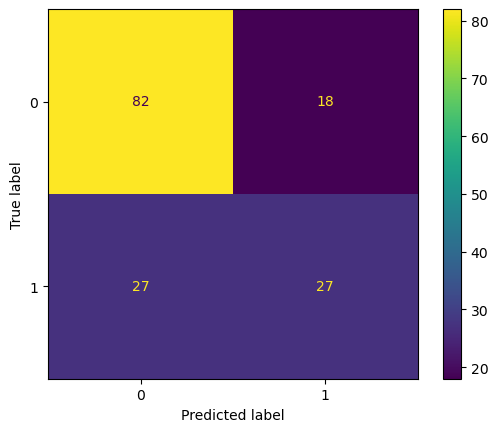

Accuracy 0.7077922077922078
Precision 0.6
Recall 0.5
F1 0.5454545454545454
Glucose                     1.182511
BMI                         0.688735
Pregnancies                 0.377502
DiabetesPedigreeFunction    0.233386
Age                         0.147798
Insulin                    -0.066157
BloodPressure              -0.044066
SkinThickness               0.028225
dtype: float64


In [8]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
pred=model.predict(X_test)
prob=model.predict_proba(X_test)[:,1]

cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()
print('Accuracy',accuracy_score(y_test,pred))
print('Precision',precision_score(y_test,pred))
print('Recall',recall_score(y_test,pred))
print('F1',f1_score(y_test,pred))
coef=pd.Series(model.coef_[0],index=X.columns).sort_values(key=abs,ascending=False)
print(coef)

In [9]:
# High risk non-diabetic cases
res=pd.DataFrame({'Actual':y_test.values,'Pred':pred,'Prob':prob})
print(res[(res.Actual==0)&(res.Prob>0.4)].sort_values('Prob',ascending=False).head(10))

     Actual  Pred      Prob
108       0     1  0.906454
34        0     1  0.884150
134       0     1  0.878135
120       0     1  0.849946
9         0     1  0.838590
18        0     1  0.813259
97        0     1  0.766945
16        0     1  0.723256
123       0     1  0.691218
33        0     1  0.645237


After balancing
Accuracy 0.7337662337662337
Precision 0.6065573770491803
Recall 0.6851851851851852
F1 0.6434782608695652


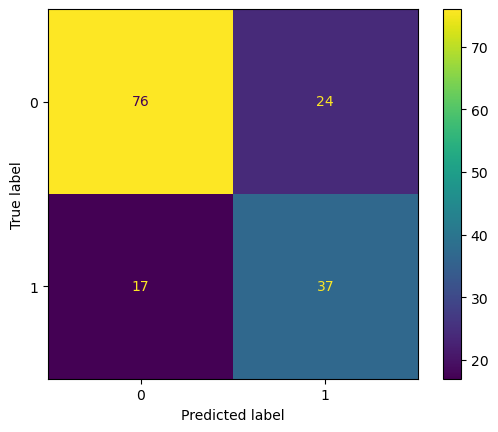

In [10]:
# Simple oversampling
train=pd.DataFrame(X_train)
train['Outcome']=y_train.reset_index(drop=True)
maj=train[train.Outcome==0]
mino=train[train.Outcome==1]
mino_up=resample(mino,replace=True,n_samples=len(maj),random_state=42)
bal=pd.concat([maj,mino_up])
Xb=bal.drop('Outcome',axis=1)
yb=bal['Outcome']
m2=LogisticRegression(max_iter=1000)
m2.fit(Xb,yb)
p2=m2.predict(X_test)
print('After balancing')
print('Accuracy',accuracy_score(y_test,p2))
print('Precision',precision_score(y_test,p2))
print('Recall',recall_score(y_test,p2))
print('F1',f1_score(y_test,p2))
ConfusionMatrixDisplay(confusion_matrix(y_test,p2)).plot()
plt.show()

In [11]:
# Threshold analysis
ths=[0.3,0.5,0.7]
for t in ths:
    pr=(prob>=t).astype(int)
    print('\nThreshold',t)
    print('Precision',precision_score(y_test,pr))
    print('Recall',recall_score(y_test,pr))
    print('F1',f1_score(y_test,pr))


Threshold 0.3
Precision 0.5972222222222222
Recall 0.7962962962962963
F1 0.6825396825396826

Threshold 0.5
Precision 0.6
Recall 0.5
F1 0.5454545454545454

Threshold 0.7
Precision 0.7142857142857143
Recall 0.37037037037037035
F1 0.4878048780487805


## Conclusions
1. Glucose, BMI, Age and Pregnancies usually have strongest influence.
2. Dataset is moderately imbalanced.
3. Confusion matrix, Precision, Recall and F1 evaluate healthcare performance.
4. Recall is important to reduce false negatives.
5. High-risk non-diabetic patients may need follow-up screening.
6. False negatives are more dangerous than false positives.
7. Visualizations: class distribution, confusion matrix, correlation heatmap.